Cargando línea de costa de alta resolución...
Proyectando a sistema métrico (Azimuthal Equidistant)...
Sanitizando geometrías para evitar TopologyException...
Calculando franja oceánica de 100 km...
Rasterizando la máscara a la grilla de CMEMS...
Aplicando máscara y promediando...
Generando gráfico...


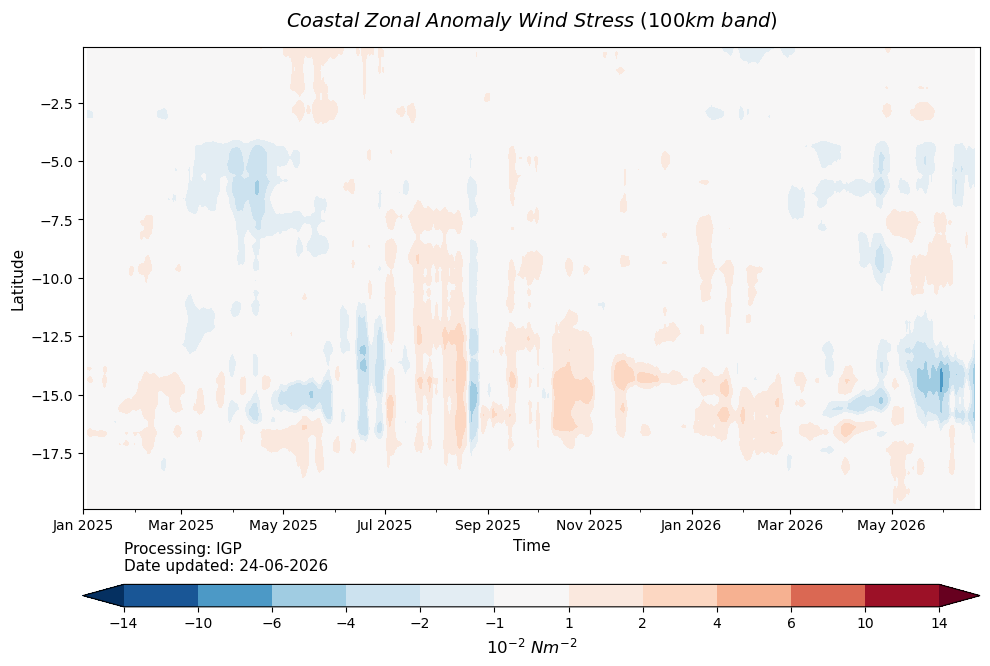

In [14]:
import xarray as xr
import numpy as np
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import os
from shapely.geometry import box
from datetime import datetime

patronFiles = "ds_anom_corregida_*.nc"
pathDir     = "/data/datos/ASCAT/KOBI/ANOMALIAS_CORREGIDAS/"

listFiles = [x for x in glob.glob(f"{pathDir}{patronFiles}") if int(os.path.basename(x).split("_")[-1][0:4])>=2025 ]

ds = xr.open_mfdataset(listFiles,concat_dim='time',combine='nested',data_vars="minimal",coords="minimal",compat="override",engine='h5netcdf')
ds = ds.sel(lat = slice(-20,0), lon = slice(-85,-65))

# ==============================================================================
# 2. CREACIÓN DE LA MÁSCARA COSTERA (TOPOLOGÍA EXACTA)
# ==============================================================================
print("Cargando línea de costa de alta resolución...")
land_gdf = gpd.read_file('/data/users/cah/ELNINO/elnino1/SHAPEFILES/ne_10m_land.shp')

# Obtenemos los límites del dataset
min_lon, max_lon = float(ds.lon.min()), float(ds.lon.max())
min_lat, max_lat = float(ds.lat.min()), float(ds.lat.max())

# --- CORRECCIÓN GEOMÉTRICA ---
# Definimos la caja física y cortamos el polígono continental
caja_limite = box(min_lon - 2, min_lat - 2, max_lon + 2, max_lat + 2)
land_clipped = land_gdf.clip(caja_limite)

print("Proyectando a sistema métrico (Azimuthal Equidistant)...")
centro_lon = (min_lon + max_lon) / 2
centro_lat = (min_lat + max_lat) / 2
crs_aeqd = f"+proj=aeqd +lat_0={centro_lat} +lon_0={centro_lon} +datum=WGS84 +units=m +no_defs"

land_proj = land_clipped.to_crs(crs_aeqd)

print("Sanitizando geometrías para evitar TopologyException...")
land_proj['geometry'] = land_proj.geometry.buffer(0)

print("Calculando franja oceánica de 100 km...")
# 1. Unir todas las islas y continentes (Actualizado a union_all() por deprecación)
tierra_union = land_proj.geometry.union_all()

# 2. Crear un buffer matemático de 100,000 metros (100 km) hacia afuera y adentro
buffer_100km = tierra_union.buffer(100000)

# 3. La franja oceánica pura es el buffer menos la porción de tierra
franja_oceanica_proj = buffer_100km.difference(tierra_union)

# 4. Retornar la geometría resultante al CRS original de los datos CMEMS (WGS84)
franja_gdf = gpd.GeoDataFrame(geometry=[franja_oceanica_proj], crs=crs_aeqd)
franja_wgs84 = franja_gdf.to_crs("EPSG:4326")

print("Rasterizando la máscara a la grilla de CMEMS...")
mask_region = regionmask.Regions(franja_wgs84.geometry)
mask_da = mask_region.mask(ds.lon, ds.lat)

mask_100km = (mask_da == 0)

# ==============================================================================
# 3. EXTRACCIÓN Y CÁLCULO DEL HOVMÖLLER
# ==============================================================================
print("Aplicando máscara y promediando...")
# Filtramos el dataset original
ds_costero = ds.where(mask_100km)

# Promedio zonal (sobre las longitudes filtradas) para cada latitud.
# Esto colapsa la matriz a Latitud vs Tiempo.
#hovmoller = ds_costero['northward_stress'].mean(dim='lon').compute() 
hovmoller = ds_costero['eastward_stress'].mean(dim='lon').compute() 

# ==============================================================================
# 4. PLOTEO DEL MAPA DE HOVMÖLLER
# ==============================================================================
print("Generando gráfico...")
fig, ax = plt.subplots(figsize=(10, 7)) 

# --- NIVELES DISCRETOS EXACTOS (De la imagen de referencia) ---
niveles = [-14, -10, -6, -4, -2,-1,1, 2, 4, 6, 10, 14]
hovmoller = hovmoller.sortby('time')
hovmoller_smooth = hovmoller.rolling(time=7,center=True).mean()
# Usamos contourf mapeando explícitamente los niveles
c = ax.contourf(
    hovmoller_smooth.time, 
    hovmoller_smooth.lat, 
    hovmoller_smooth.T*100, 
    levels=niveles, 
    cmap='RdBu_r', 
    extend='both'
)

# Configuración de ejes
ax.set_title(r'$Coastal\ Zonal\ Anomaly\ Wind\ Stress\ (100km\ band)$', fontsize=14, pad=15)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_xlabel('Time', fontsize=11)

# Formateo del Eje X
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=0, ha='center')

# --- CONFIGURACIÓN DEL COLORBAR ---
# Lo colocamos horizontalmente y en la parte inferior
cbar = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.12, aspect=40)
cbar.set_ticks(niveles) # Forzamos a que muestre todos los números
cbar.set_label(r'$10^{-2}\ N m^{-2}$', fontsize=12)

# --- TEXTOS DE CABECERA DEL COLORBAR ---
# Generamos la fecha actual dinámicamente en formato DD-MM-YYYY
fecha_hoy = datetime.now().strftime('%d-%m-%Y')
texto_header = f"Processing: IGP\nDate updated: {fecha_hoy}"

# Anclamos el texto a la esquina superior izquierda del colorbar
cbar.ax.set_title(texto_header, loc='left', fontsize=11, pad=10)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

Generando gráfico...


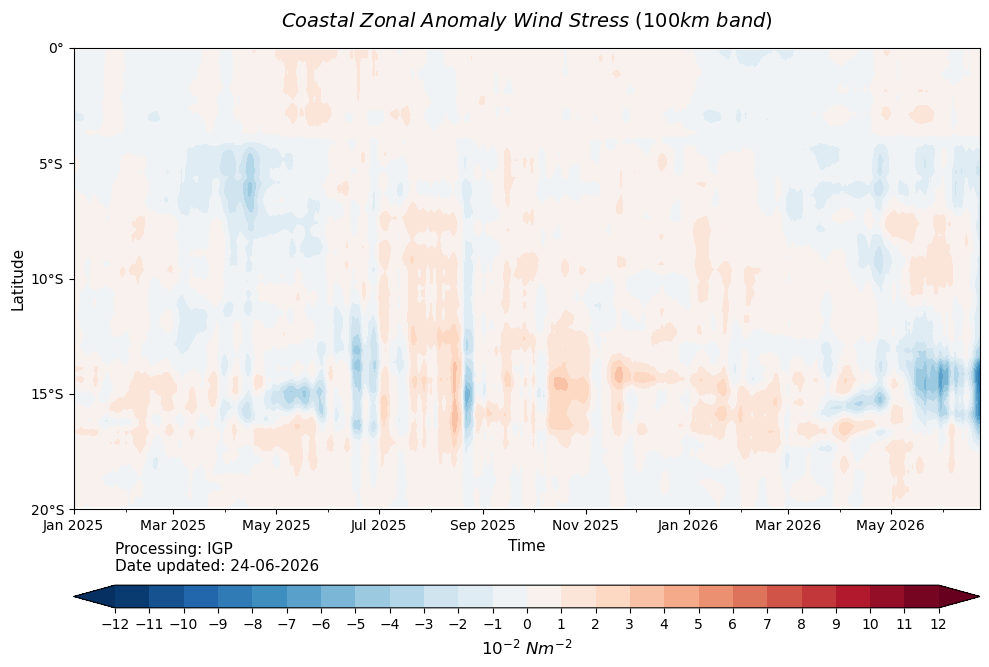

In [15]:
from datetime import datetime
import matplotlib.dates as mdates
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 4. PLOTEO DEL MAPA DE HOVMÖLLER
# ==============================================================================
print("Generando gráfico...")
fig, ax = plt.subplots(figsize=(10, 7)) 

# --- RECUPERACIÓN DE DATOS FALTANTES (Evita huecos blancos) ---
hovmoller = hovmoller.sortby('time')
# Interpolamos para tapar vacíos satelitales antes de suavizar
# hovmoller_clean = hovmoller.interpolate_na(dim='time', method='linear', limit=5)
hovmoller_smooth = hovmoller.rolling(time=7, center=True, min_periods=1).mean()

# --- NUEVOS NIVELES DISCRETOS (-12 a 12, incluyendo el 0) ---
#niveles = [-12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12]
niveles = np.arange(-12, 13, 1)

# Usamos contourf mapeando explícitamente los niveles
c = ax.contourf(
    hovmoller_smooth.time, 
    hovmoller_smooth.lat, # Asegúrate de que tu variable sea 'latitude' o 'lat' según tu dataset
    hovmoller_smooth.T * 100, 
    levels=niveles, 
    cmap='RdBu_r', 
    extend='both'
)

# ==============================================================================
# CONFIGURACIÓN DE EJES (Con etiquetas de Latitud detalladas)
# ==============================================================================
ax.set_title(r'$Coastal\ Zonal\ Anomaly\ Wind\ Stress\ (100km\ band)$', fontsize=14, pad=15)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_xlabel('Time', fontsize=11)

# --- CONFIGURACIÓN EJE Y (Latitudes) ---
ticks_lat = np.arange(-20, 1, 5) # Genera [-20, -15, -10, -5, 0]
ax.set_yticks(ticks_lat)
# Formato pro: reemplaza los negativos por "°S" y el 0 por "0°" (o "Eq")
ax.set_yticklabels([f'{abs(lat)}°S' if lat < 0 else '0°' for lat in ticks_lat])

# --- CONFIGURACIÓN EJE X (Tiempo) ---
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=0, ha='center')

# ==============================================================================
# CONFIGURACIÓN DEL COLORBAR
# ==============================================================================
# Lo colocamos horizontalmente y en la parte inferior
cbar = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.12, aspect=40)
cbar.set_ticks(niveles) # Forzamos a que muestre todos los números, incluido el 0
cbar.set_label(r'$10^{-2}\ N m^{-2}$', fontsize=12)

# --- TEXTOS DE CABECERA DEL COLORBAR ---
fecha_hoy = datetime.now().strftime('%d-%m-%Y')
texto_header = f"Processing: IGP\nDate updated: {fecha_hoy}"

# Anclamos el texto a la esquina superior izquierda del colorbar
cbar.ax.set_title(texto_header, loc='left', fontsize=11, pad=10)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

Aplicando máscara y promediando...
Generando gráfico...


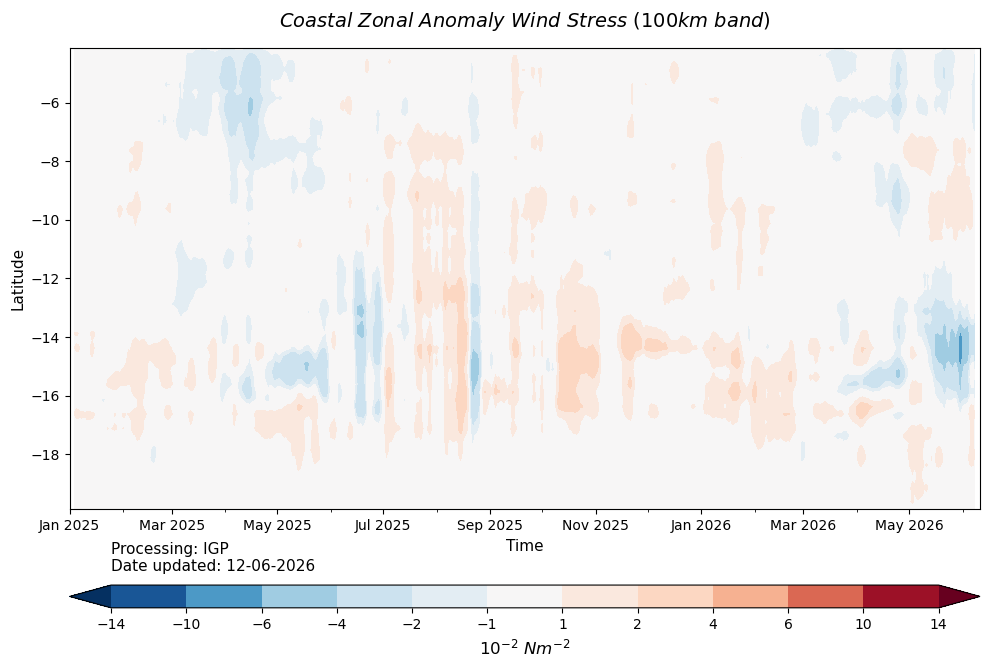

In [2]:
# ==============================================================================
# 3. EXTRACCIÓN Y CÁLCULO DEL HOVMÖLLER
# ==============================================================================
print("Aplicando máscara y promediando...")
# Filtramos el dataset original
ds_costero = ds.where(mask_100km)

# Promedio zonal (sobre las longitudes filtradas) para cada latitud.
# Esto colapsa la matriz a Latitud vs Tiempo.
hovmoller = ds_costero['eastward_stress'].mean(dim='lon').compute() 


# ==============================================================================
# 4. PLOTEO DEL MAPA DE HOVMÖLLER
# ==============================================================================
print("Generando gráfico...")
fig, ax = plt.subplots(figsize=(10, 7)) 

# --- NIVELES DISCRETOS EXACTOS (De la imagen de referencia) ---
niveles = [-14, -10, -6, -4, -2,-1,1,2, 4, 6, 10, 14]
hovmoller = hovmoller.sortby('time')
hovmoller_smooth = hovmoller.rolling(time=7,center=True).mean()
# Usamos contourf mapeando explícitamente los niveles
c = ax.contourf(
    hovmoller_smooth.time, 
    hovmoller_smooth.lat, 
    hovmoller_smooth.T*100, 
    levels=niveles, 
    cmap='RdBu_r', 
    extend='both'
)

# Configuración de ejes
ax.set_title(r'$Coastal\ Zonal\ Anomaly\ Wind\ Stress\ (100km\ band)$', fontsize=14, pad=15)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_xlabel('Time', fontsize=11)

# Formateo del Eje X
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=0, ha='center')

# --- CONFIGURACIÓN DEL COLORBAR ---
# Lo colocamos horizontalmente y en la parte inferior
cbar = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.12, aspect=40)
cbar.set_ticks(niveles) # Forzamos a que muestre todos los números
cbar.set_label(r'$10^{-2}\ N m^{-2}$', fontsize=12)

# --- TEXTOS DE CABECERA DEL COLORBAR ---
# Generamos la fecha actual dinámicamente en formato DD-MM-YYYY
fecha_hoy = datetime.now().strftime('%d-%m-%Y')
texto_header = f"Processing: IGP\nDate updated: {fecha_hoy}"

# Anclamos el texto a la esquina superior izquierda del colorbar
cbar.ax.set_title(texto_header, loc='left', fontsize=11, pad=10)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

Cargando línea de costa de alta resolución...
Proyectando a sistema métrico (Azimuthal Equidistant)...
Sanitizando geometrías para evitar TopologyException...
Calculando franja oceánica de 100 km...
Rasterizando la máscara a la grilla de CMEMS...
Aplicando máscara y promediando...
Generando gráfico...


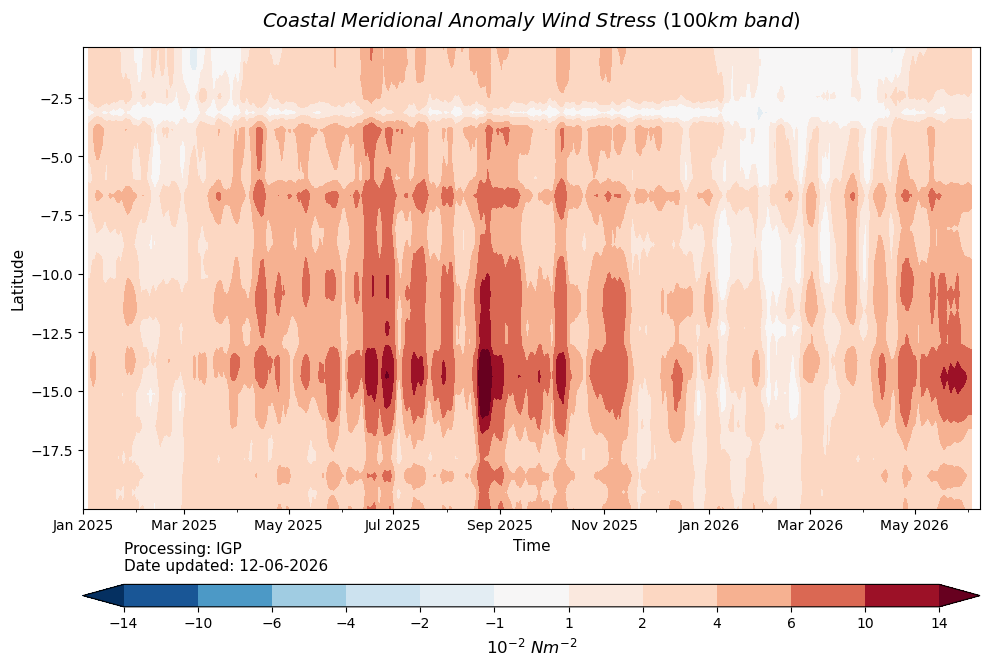

In [5]:
import xarray as xr
import numpy as np
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import os
from shapely.geometry import box
from datetime import datetime

patronFiles = "flx_diario_*.nc"
pathDir     = "/data/datos/CORE/WINDSTRESS_DIARIO_NC/"

listFiles = [x for x in glob.glob(f"{pathDir}{patronFiles}") if int(os.path.basename(x).split("_")[-1][0:4])>=2025 ]

ds = xr.open_mfdataset(listFiles,concat_dim='time',combine='nested',data_vars="minimal",coords="minimal",
                       compat="override").rename({'latitude':'lat','longitude':'lon'}).sortby(['lat','time'])
ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
ds = ds.sortby('lon').sel(lat = slice(-20,0), lon = slice(-90,-65))

# ==============================================================================
# 2. CREACIÓN DE LA MÁSCARA COSTERA (TOPOLOGÍA EXACTA)
# ==============================================================================
print("Cargando línea de costa de alta resolución...")
land_gdf = gpd.read_file('/data/users/cah/ELNINO/elnino1/SHAPEFILES/ne_10m_land.shp')

# Obtenemos los límites del dataset
min_lon, max_lon = float(ds.lon.min()), float(ds.lon.max())
min_lat, max_lat = float(ds.lat.min()), float(ds.lat.max())

# --- CORRECCIÓN GEOMÉTRICA ---
# Definimos la caja física y cortamos el polígono continental
caja_limite = box(min_lon - 2, min_lat - 2, max_lon + 2, max_lat + 2)
land_clipped = land_gdf.clip(caja_limite)

print("Proyectando a sistema métrico (Azimuthal Equidistant)...")
centro_lon = (min_lon + max_lon) / 2
centro_lat = (min_lat + max_lat) / 2
crs_aeqd = f"+proj=aeqd +lat_0={centro_lat} +lon_0={centro_lon} +datum=WGS84 +units=m +no_defs"

land_proj = land_clipped.to_crs(crs_aeqd)

print("Sanitizando geometrías para evitar TopologyException...")
land_proj['geometry'] = land_proj.geometry.buffer(0)

print("Calculando franja oceánica de 100 km...")
# 1. Unir todas las islas y continentes (Actualizado a union_all() por deprecación)
tierra_union = land_proj.geometry.union_all()

# 2. Crear un buffer matemático de 100,000 metros (100 km) hacia afuera y adentro
buffer_100km = tierra_union.buffer(100000)

# 3. La franja oceánica pura es el buffer menos la porción de tierra
franja_oceanica_proj = buffer_100km.difference(tierra_union)

# 4. Retornar la geometría resultante al CRS original de los datos CMEMS (WGS84)
franja_gdf = gpd.GeoDataFrame(geometry=[franja_oceanica_proj], crs=crs_aeqd)
franja_wgs84 = franja_gdf.to_crs("EPSG:4326")

print("Rasterizando la máscara a la grilla de CMEMS...")
mask_region = regionmask.Regions(franja_wgs84.geometry)
mask_da = mask_region.mask(ds.lon, ds.lat)

mask_100km = (mask_da == 0)

# ==============================================================================
# 3. EXTRACCIÓN Y CÁLCULO DEL HOVMÖLLER
# ==============================================================================
print("Aplicando máscara y promediando...")
# Filtramos el dataset original
ds_costero = ds.where(mask_100km)

# Promedio zonal (sobre las longitudes filtradas) para cada latitud.
# Esto colapsa la matriz a Latitud vs Tiempo.
hovmoller = ds_costero['VFLX_surface'].mean(dim='lon').compute() 


# ==============================================================================
# 4. PLOTEO DEL MAPA DE HOVMÖLLER
# ==============================================================================
print("Generando gráfico...")
fig, ax = plt.subplots(figsize=(10, 7)) 

# --- NIVELES DISCRETOS EXACTOS (De la imagen de referencia) ---
niveles = [-14, -10, -6, -4, -2,-1,1, 2, 4, 6, 10, 14]
hovmoller = hovmoller.sortby('time')
hovmoller_smooth = hovmoller.rolling(time=7,center=True).mean()
# Usamos contourf mapeando explícitamente los niveles
c = ax.contourf(
    hovmoller_smooth.time, 
    hovmoller_smooth.lat, 
    hovmoller_smooth.T*-100, 
    levels=niveles, 
    cmap='RdBu_r', 
    extend='both'
)

# Configuración de ejes
ax.set_title(r'$Coastal\ Meridional\ Anomaly\ Wind\ Stress\ (100km\ band)$', fontsize=14, pad=15)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_xlabel('Time', fontsize=11)

# Formateo del Eje X
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=0, ha='center')

# --- CONFIGURACIÓN DEL COLORBAR ---
# Lo colocamos horizontalmente y en la parte inferior
cbar = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.12, aspect=40)
cbar.set_ticks(niveles) # Forzamos a que muestre todos los números
cbar.set_label(r'$10^{-2}\ N m^{-2}$', fontsize=12)

# --- TEXTOS DE CABECERA DEL COLORBAR ---
# Generamos la fecha actual dinámicamente en formato DD-MM-YYYY
fecha_hoy = datetime.now().strftime('%d-%m-%Y')
texto_header = f"Processing: IGP\nDate updated: {fecha_hoy}"

# Anclamos el texto a la esquina superior izquierda del colorbar
cbar.ax.set_title(texto_header, loc='left', fontsize=11, pad=10)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

Cargando climatologías...
Calculando anomalías dinámicas...
Cargando línea de costa de alta resolución...
Proyectando a sistema métrico...
Calculando franja oceánica de 100 km...
Rasterizando la máscara...
Aplicando máscara y promediando...
Generando gráfico...


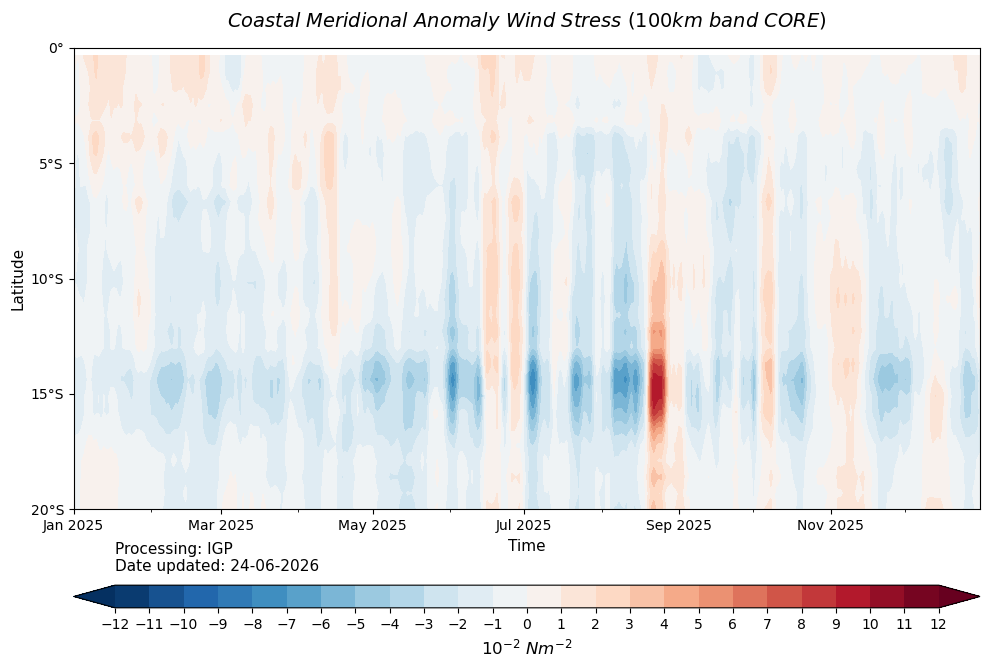

In [5]:
import xarray as xr
import numpy as np
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import os
import calendar
from shapely.geometry import box
from datetime import datetime

# ==============================================================================
# 1. CARGA DE DATOS OBSERVADOS
# ==============================================================================
patronFiles = "flx_diario_*.nc"
pathDir     = "/data/datos/CORE/WINDSTRESS_DIARIO_NC/"

listFiles = [x for x in glob.glob(f"{pathDir}{patronFiles}") if int(os.path.basename(x).split("_")[-1][0:4])>=2025 ]

# Carga de datos observados
ds = xr.open_mfdataset(
    listFiles, concat_dim='time', combine='nested', 
    data_vars="minimal", coords="minimal", compat="override"
).rename({'latitude':'lat','longitude':'lon'}).sortby('time')

# --- CONVERSIÓN DE LONGITUD Y ORDENAMIENTO ---
ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
ds = ds.sortby(['lat', 'lon', 'time']).drop_duplicates(dim='time')

# Recorte espacial
ds = ds.sel(lat = slice(-20,0), lon = slice(-90,-65))

# ==============================================================================
# 1.5 CARGA DE CLIMATOLOGÍAS Y CÁLCULO DE ANOMALÍAS
# ==============================================================================
print("Cargando climatologías...")

def preprocesar_clim(ruta):
    # Abrimos, renombramos y aplicamos el mismo formato de longitud (-180 a 180)
    dc = xr.open_dataset(ruta).rename({'latitude':'lat', 'longitude':'lon'})
    dc.coords['lon'] = (dc.coords['lon'] + 180) % 360 - 180
    dc = dc.sortby(['lat', 'lon']).sel(lat=slice(-20,0), lon=slice(-90,-65))
    return dc.load() # load() sube la climatología a RAM para acelerar el cálculo

clim_leap = preprocesar_clim('/data/datos/CORE/CLIM_CORE/clim_diario_coreLeap.nc')
clim_norm = preprocesar_clim('/data/datos/CORE/CLIM_CORE/clim_diario_core.nc')

print("Calculando anomalías dinámicas...")
anomalias_anuales = []
años_observados = np.unique(ds['time'].dt.year.values)

for y in años_observados:
    # 1. Aislamos el año en curso
    ds_y = ds.sel(time=str(y))
    
    # 2. Elegimos la climatología correspondiente
    clim_usar = clim_leap if calendar.isleap(y) else clim_norm
    
    # 3. Alineación exacta por "Día del Año" (dayofyear: 1 a 365/366)
    # Restamos 1 porque los índices en Python empiezan en 0
    indices_doy = ds_y['time'].dt.dayofyear.values - 1
    
    # Extraemos solo los valores numéricos correspondientes a esos días precisos
    # Asumimos que tu variable dentro de la climatología también se llama 'VFLX_surface'
    clim_vals = clim_usar['VFLX_surface'].isel(time=indices_doy).values
    
    # 4. Resta directa de matrices
    anom_y = ds_y['VFLX_surface'] - clim_vals
    anomalias_anuales.append(anom_y)

# Reconstruimos la serie temporal continua y reemplazamos la variable cruda
ds['VFLX_surface'] = xr.concat(anomalias_anuales, dim='time')

# ==============================================================================
# 2. CREACIÓN DE LA MÁSCARA COSTERA (TOPOLOGÍA EXACTA)
# ==============================================================================
print("Cargando línea de costa de alta resolución...")
land_gdf = gpd.read_file('/data/users/cah/ELNINO/elnino1/SHAPEFILES/ne_10m_land.shp')

min_lon, max_lon = float(ds.lon.min()), float(ds.lon.max())
min_lat, max_lat = float(ds.lat.min()), float(ds.lat.max())

caja_limite = box(min_lon - 2, min_lat - 2, max_lon + 2, max_lat + 2)
land_clipped = land_gdf.clip(caja_limite)

print("Proyectando a sistema métrico...")
centro_lon = (min_lon + max_lon) / 2
centro_lat = (min_lat + max_lat) / 2
crs_aeqd = f"+proj=aeqd +lat_0={centro_lat} +lon_0={centro_lon} +datum=WGS84 +units=m +no_defs"

land_proj = land_clipped.to_crs(crs_aeqd)
land_proj['geometry'] = land_proj.geometry.buffer(0)

print("Calculando franja oceánica de 100 km...")
tierra_union = land_proj.geometry.union_all()
buffer_100km = tierra_union.buffer(100000)
franja_oceanica_proj = buffer_100km.difference(tierra_union)

franja_gdf = gpd.GeoDataFrame(geometry=[franja_oceanica_proj], crs=crs_aeqd)
franja_wgs84 = franja_gdf.to_crs("EPSG:4326")

print("Rasterizando la máscara...")
mask_region = regionmask.Regions(franja_wgs84.geometry)
mask_da = mask_region.mask(ds.lon, ds.lat)

mask_100km = (mask_da == 0)

# ==============================================================================
# 3. EXTRACCIÓN Y CÁLCULO DEL HOVMÖLLER
# ==============================================================================
print("Aplicando máscara y promediando...")
ds = ds.interp(lon=mask_100km.lon,lat=mask_100km.lat)
ds_costero = ds.where(mask_100km)

# Calculamos el promedio zonal y subimos a RAM.
# Como en el paso 1.5 ya calculamos la anomalía, esto colapsará anomalías.
hovmoller = ds_costero['VFLX_surface'].mean(dim='lon').compute() 

# ==============================================================================
# 4. PLOTEO DEL MAPA DE HOVMÖLLER
# ==============================================================================
print("Generando gráfico...")
fig, ax = plt.subplots(figsize=(10, 7)) 

# --- RECUPERACIÓN Y SUAVIZADO ---
# Interpolamos para tapar vacíos y usamos min_periods=1
hovmoller_clean = hovmoller.interpolate_na(dim='time', method='linear', limit=5)
hovmoller_smooth = hovmoller_clean.rolling(time=7, center=True, min_periods=1).mean()

# --- NIVELES DISCRETOS (-12 a 12, con 0 incluido) ---
niveles = np.arange(-12, 13, 1)

# Ploteo con multiplicador negativo según tu configuración
c = ax.contourf(
    hovmoller_smooth.time, 
    hovmoller_smooth.lat, 
    hovmoller_smooth.T * -100, 
    levels=niveles, 
    cmap='RdBu_r', 
    extend='both'
)

# ==============================================================================
# CONFIGURACIÓN DE EJES 
# ==============================================================================
ax.set_title(r'$Coastal\ Meridional\ Anomaly\ Wind\ Stress\ (100km\ band\ CORE)$', fontsize=14, pad=15)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_xlabel('Time', fontsize=11)

# --- ETIQUETAS DE LATITUD MEJORADAS ---
ticks_lat = np.arange(-20, 1, 5) 
ax.set_yticks(ticks_lat)
ax.set_yticklabels([f'{abs(lat)}°S' if lat < 0 else '0°' for lat in ticks_lat])

# Formateo del Eje X
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=0, ha='center')

# --- CONFIGURACIÓN DEL COLORBAR ---
cbar = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.12, aspect=40)
cbar.set_ticks(niveles) 
cbar.set_label(r'$10^{-2}\ N m^{-2}$', fontsize=12)

# Textos de cabecera 
fecha_hoy = datetime.now().strftime('%d-%m-%Y')
texto_header = f"Processing: IGP\nDate updated: {fecha_hoy}"
cbar.ax.set_title(texto_header, loc='left', fontsize=11, pad=10)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

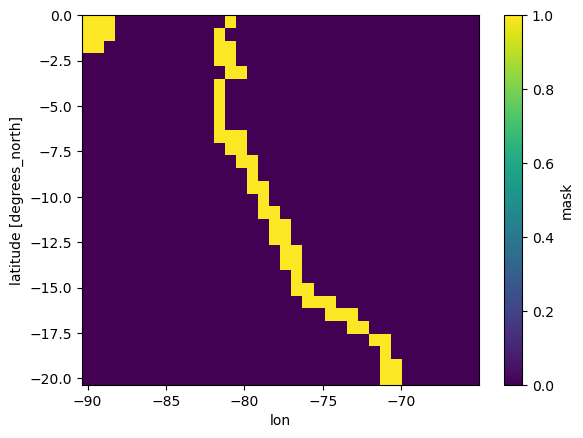

In [6]:
mask_100km.plot()

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [35]:
import xarray as xr 

ds = xr.open_dataset("/home/elnino1/sst.mnmean.nc")
dat = ds.sel(lon=slice(190,240),lat=slice(5,-5)).sortby('lat')
dat = dat.mean(['lat','lon'])
dat

<xarray.Dataset> Size: 58kB
Dimensions:    (time: 2062, nbnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 16kB 1854-01-01 1854-02-01 ... 2025-10-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB 9.969e+36 9.969e+36 ... 9.969e+36
    sst        (time) float32 8kB 25.9 26.06 26.91 27.63 ... 26.5 26.25 26.19

In [27]:
df = dat.sst.values

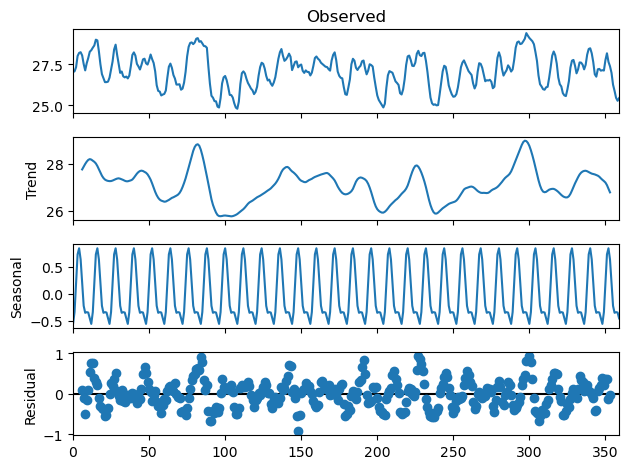

In [28]:
ax = seasonal_decompose(df,period=12).plot()

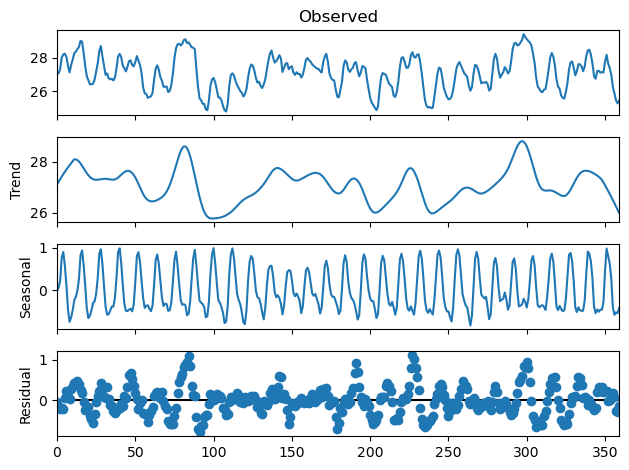

In [39]:
from statsmodels.tsa.seasonal import STL

ac = STL(df, period=12)
acd = ac.fit().plot()

In [34]:
var_total = np.var(df)

var_trend = np.var(res.trend)
var_season = np.var(res.seasonal)
var_resid = np.var(res.resid)

print(var_trend/var_total)
print(var_season/var_total)
print(var_resid/var_total)

AttributeError: 'statsmodels.tsa.stl._stl.STL' object has no attribute 'trend'

In [33]:
var_total

np.float32(1.0050969)